In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("finalLASTDataset.csv")

In [3]:
df

,cv_id,jd_id,hard_skill_match_ratio,missing_hard_skills_count,domain,feat_95,feat_69,feat_125,feat_20,feat_91,...,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8,target
0,1,1,1.000000,0,Support,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967,1
1,1,2,0.750000,1,IT,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967,1
2,1,3,0.333333,2,Business,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967,0
3,1,4,0.333333,2,Business,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967,0
4,1,5,0.625000,3,Business,-1.322632,1.406155,-2.846429,1.291473,-0.707366,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10171,32,314,0.400000,3,Business,-0.311749,-1.240845,-0.635899,2.053639,1.169260,...,-2.961040,-2.598758,-1.493966,-0.067979,0.300692,1.960421,-2.262334,0.560022,-0.958605,0
10172,32,315,0.200000,4,Business,-0.311749,-1.240845,-0.635899,2.053639,1.169260,...,-2.961040,-2.598758,-1.493966,-0.067979,0.300692,1.960421,-2.262334,0.560022,-0.958605,0
10173,32,316,0.166667,5,Business,-0.311749,-1.240845,-0.635899,2.053639,1.169260,...,-2.961040,-2.598758,-1.493966,-0.067979,0.300692,1.960421,-2.262334,0.560022,-0.958605,0
10174,32,317,0.333333,2,Business,-0.311749,-1.240845,-0.635899,2.053639,1.169260,...,-2.961040,-2.598758,-1.493966,-0.067979,0.300692,1.960421,-2.262334,0.560022,-0.958605,0


#Encoding

In [4]:
df = pd.get_dummies(df, columns=['domain'], prefix='domain', dtype=int)

In [5]:
df

,cv_id,jd_id,hard_skill_match_ratio,missing_hard_skills_count,feat_95,feat_69,feat_125,feat_20,feat_91,feat_68,...,domain_Consulting,domain_Creative,domain_Engineering,domain_Finance,domain_HR,domain_IT,domain_Management,domain_Operations,domain_Research,domain_Support
0,1,1,1.000000,0,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,...,0,0,0,0,0,0,0,0,0,1
1,1,2,0.750000,1,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,...,0,0,0,0,0,1,0,0,0,0
2,1,3,0.333333,2,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,...,0,0,0,0,0,0,0,0,0,0
3,1,4,0.333333,2,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,...,0,0,0,0,0,0,0,0,0,0
4,1,5,0.625000,3,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10171,32,314,0.400000,3,-0.311749,-1.240845,-0.635899,2.053639,1.169260,0.429583,...,0,0,0,0,0,0,0,0,0,0
10172,32,315,0.200000,4,-0.311749,-1.240845,-0.635899,2.053639,1.169260,0.429583,...,0,0,0,0,0,0,0,0,0,0
10173,32,316,0.166667,5,-0.311749,-1.240845,-0.635899,2.053639,1.169260,0.429583,...,0,0,0,0,0,0,0,0,0,0
10174,32,317,0.333333,2,-0.311749,-1.240845,-0.635899,2.053639,1.169260,0.429583,...,0,0,0,0,0,0,0,0,0,0


In [6]:
from sklearn.model_selection import GroupShuffleSplit

X = df.drop(columns=["target","cv_id","jd_id"])
y = df["target"]
groups = df["cv_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_valid_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_valid, y_train_valid, groups_train_valid = (
    X.iloc[train_valid_idx],
    y.iloc[train_valid_idx],
    groups.iloc[train_valid_idx],
)
X_test, y_test, groups_test = X.iloc[test_idx], y.iloc[test_idx], groups.iloc[test_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, valid_idx = next(gss2.split(X_train_valid, y_train_valid, groups=groups_train_valid))

X_train, y_train = X_train_valid.iloc[train_idx], y_train_valid.iloc[train_idx]
X_valid, y_valid = X_train_valid.iloc[valid_idx], y_train_valid.iloc[valid_idx]

In [9]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [10]:
probs = tree.predict_proba(X_valid)[:, 1]

sorted_idx = np.argsort(probs)[::-1]
y_sorted = y_valid.values[sorted_idx]

In [11]:
def precision_at_k(y_true_sorted, k):
    return y_true_sorted[:k].sum() / k

def mean_reciprocal_rank(y_true_sorted):
    for i, val in enumerate(y_true_sorted, start=1):
        if val == 1:
            return 1 / i
    return 0

In [12]:
p_at_5 = precision_at_k(y_sorted, 5)
mrr = mean_reciprocal_rank(y_sorted)

print(f"Precision@5 = {p_at_5:.3f}")
print(f"MRR = {mrr:.3f}")

Precision@5 = 0.800
MRR = 0.500


In [13]:
depths = [2, 3, 4, 5,6,7]
results = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    probs = tree.predict_proba(X_valid)[:, 1]
    sorted_idx = np.argsort(probs)[::-1]
    y_sorted = y_valid.values[sorted_idx]

    p_at_5 = precision_at_k(y_sorted, 5)
    mrr = mean_reciprocal_rank(y_sorted)

    results.append((depth, p_at_5, mrr))

# Print results
for depth, p_at_5, mrr in results:
    print(f"Depth={depth}, Precision@5={p_at_5:.3f}, MRR={mrr:.3f}")

Depth=2, Precision@5=0.200, MRR=0.500
Depth=3, Precision@5=0.800, MRR=0.500
Depth=4, Precision@5=1.000, MRR=1.000
Depth=5, Precision@5=0.000, MRR=0.036
Depth=6, Precision@5=0.000, MRR=0.056
Depth=7, Precision@5=0.200, MRR=0.500


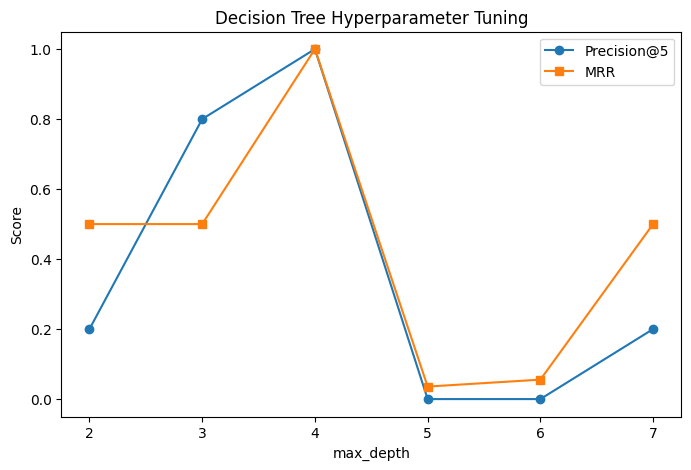

In [14]:
# Plot Precision@5 and MRR vs max_depth
depths = [r[0] for r in results]
precisions = [r[1] for r in results]
mrrs = [r[2] for r in results]

plt.figure(figsize=(8,5))
plt.plot(depths, precisions, marker='o', label="Precision@5")
plt.plot(depths, mrrs, marker='s', label="MRR")
plt.xlabel("max_depth")
plt.ylabel("Score")
plt.title("Decision Tree Hyperparameter Tuning")
plt.legend()
plt.show()

In [15]:
split_values = [2, 3,4,5]
results_split = []

for split in split_values:
    tree = DecisionTreeClassifier(max_depth=4, min_samples_split=split, random_state=42)
    tree.fit(X_train, y_train)

    probs = tree.predict_proba(X_valid)[:, 1]
    sorted_idx = np.argsort(probs)[::-1]
    y_sorted = y_valid.values[sorted_idx]

    p_at_5 = precision_at_k(y_sorted, 5)
    mrr = mean_reciprocal_rank(y_sorted)

    results_split.append((split, p_at_5, mrr))

# Print results
for split, p_at_5, mrr in results_split:
    print(f"min_samples_split={split}, Precision@5={p_at_5:.3f}, MRR={mrr:.3f}")

min_samples_split=2, Precision@5=1.000, MRR=1.000
min_samples_split=3, Precision@5=1.000, MRR=1.000
min_samples_split=4, Precision@5=1.000, MRR=1.000
min_samples_split=5, Precision@5=1.000, MRR=1.000


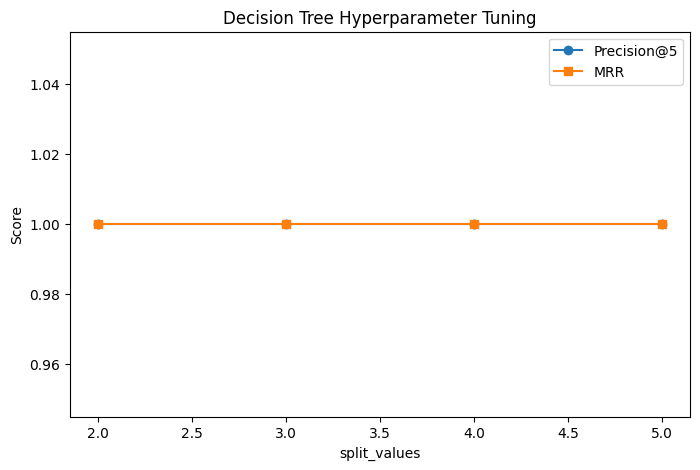

In [16]:
split_values = [r[0] for r in results_split]
precisions = [r[1] for r in results_split]
mrrs = [r[2] for r in results_split]

plt.figure(figsize=(8,5))
plt.plot(split_values, precisions, marker='o', label="Precision@5")
plt.plot(split_values, mrrs, marker='s', label="MRR")
plt.xlabel("split_values")
plt.ylabel("Score")
plt.title("Decision Tree Hyperparameter Tuning")
plt.legend()
plt.show()

In [17]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
results = []

In [18]:
for depth in depths:
  p_at_5_scores = []
  mrr_scores = []
  for train_idx, valid_idx in gkf.split(X, y, groups=groups):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    probs = tree.predict_proba(X_valid)[:, 1]
    sorted_idx = np.argsort(probs)[::-1]
    y_sorted = y_valid.values[sorted_idx]

    p_at_5_scores.append(precision_at_k(y_sorted, 5))
    mrr_scores.append(mean_reciprocal_rank(y_sorted))
  results.append((depth, np.mean(p_at_5_scores), np.mean(mrr_scores)))

In [19]:
results

[(2, np.float64(0.6799999999999999), np.float64(0.8)),
 (3, np.float64(0.52), np.float64(0.5372670807453416)),
 (4, np.float64(0.52), np.float64(0.6066666666666667)),
 (5, np.float64(0.5599999999999999), np.float64(0.528)),
 (6, np.float64(0.52), np.float64(0.6466666666666667)),
 (7, np.float64(0.4), np.float64(0.5291666666666667))]

In [20]:
depths = [r[0] for r in results]
precisions = [r[1] for r in results]
mrrs = [r[2] for r in results]

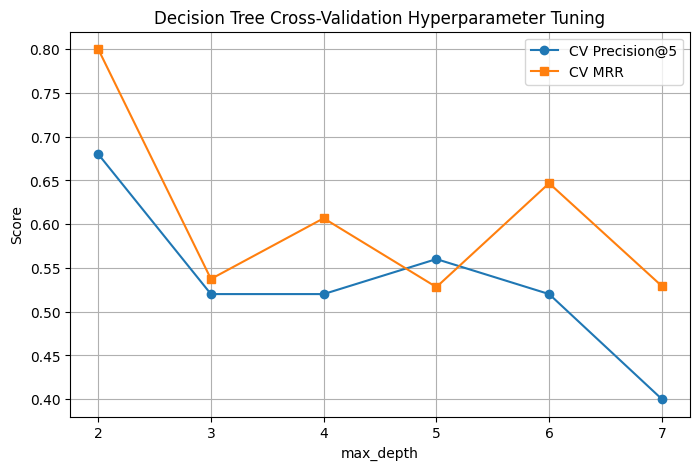

In [21]:
plt.figure(figsize=(8,5))
plt.plot(depths, precisions, marker='o', label="CV Precision@5")
plt.plot(depths, mrrs, marker='s', label="CV MRR")
plt.xlabel("max_depth")
plt.ylabel("Score")
plt.title("Decision Tree Cross-Validation Hyperparameter Tuning")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
best_depth = max(results, key=lambda x: x[1])[0]
print(f"Best max_depth by CV Precision@5 = {best_depth}")

Best max_depth by CV Precision@5 = 2


In [23]:
criteria = ["gini", "entropy"]
results = {}

In [24]:
def evaluate_split(model, X_split, y_split):
    probs = model.predict_proba(X_split)[:, 1]
    sorted_idx = np.argsort(probs)[::-1]
    y_sorted = y_split.values[sorted_idx]
    return precision_at_k(y_sorted, 5), mean_reciprocal_rank(y_sorted)

In [25]:
for crit in criteria:
    tree = DecisionTreeClassifier(max_depth=best_depth, criterion=crit, random_state=42)
    tree.fit(X_train, y_train)

    p_at_5_train, mrr_train = evaluate_split(tree, X_train, y_train)
    p_at_5_valid, mrr_valid = evaluate_split(tree, X_valid, y_valid)
    p_at_5_test, mrr_test = evaluate_split(tree, X_test, y_test)

    results[crit] = {
        "Train": (p_at_5_train, mrr_train),
        "Validation": (p_at_5_valid, mrr_valid),
        "Test": (p_at_5_test, mrr_test)
    }

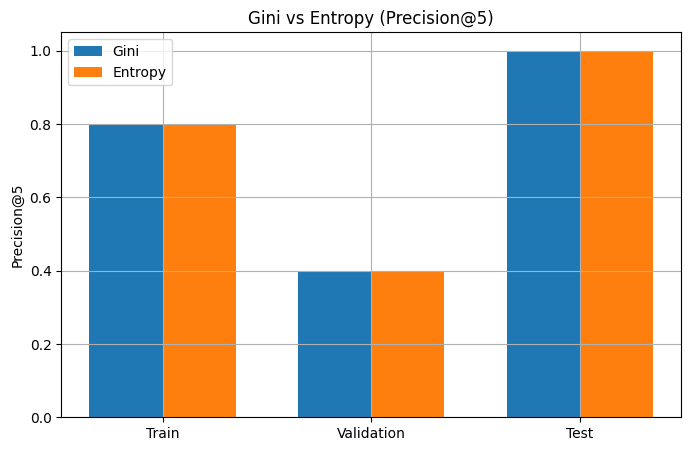

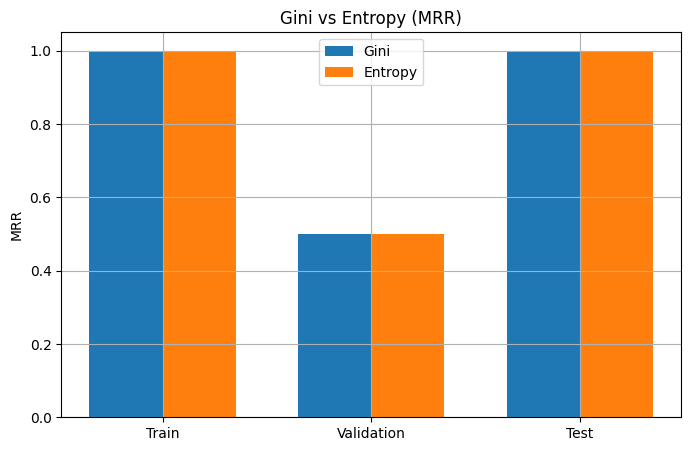

In [26]:
labels = ["Train", "Validation", "Test"]
x = np.arange(len(labels))
width = 0.35

for metric_idx, metric_name in enumerate(["Precision@5", "MRR"]):
    plt.figure(figsize=(8,5))
    gini_vals = [results["gini"][split][metric_idx] for split in labels]
    entropy_vals = [results["entropy"][split][metric_idx] for split in labels]

    plt.bar(x - width/2, gini_vals, width, label="Gini")
    plt.bar(x + width/2, entropy_vals, width, label="Entropy")
    plt.xticks(x, labels)
    plt.ylabel(metric_name)
    plt.title(f"Gini vs Entropy ({metric_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

In [27]:
Last_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
Last_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [28]:
probs = Last_tree.predict_proba(X_valid)[:, 1]

sorted_idx = np.argsort(probs)[::-1]
y_sorted = y_valid.values[sorted_idx]

In [29]:
p_at_5 = precision_at_k(y_sorted, 5)
mrr = mean_reciprocal_rank(y_sorted)

print(f"Precision@5 = {p_at_5:.3f}")
print(f"MRR = {mrr:.3f}")

Precision@5 = 0.400
MRR = 0.500


In [30]:
probsTest = Last_tree.predict_proba(X_test)[:, 1]

sorted_idx = np.argsort(probsTest)[::-1]
y_sorted = y_test.values[sorted_idx]

In [31]:
p_at_5 = precision_at_k(y_sorted, 5)
mrr = mean_reciprocal_rank(y_sorted)

print(f"Precision@5 = {p_at_5:.3f}")
print(f"MRR = {mrr:.3f}")

Precision@5 = 1.000
MRR = 1.000


In [32]:
p_at_5_train, mrr_train = evaluate_split(Last_tree, X_train, y_train)
p_at_5_valid, mrr_valid = evaluate_split(Last_tree, X_valid, y_valid)
p_at_5_test, mrr_test = evaluate_split(Last_tree, X_test, y_test)

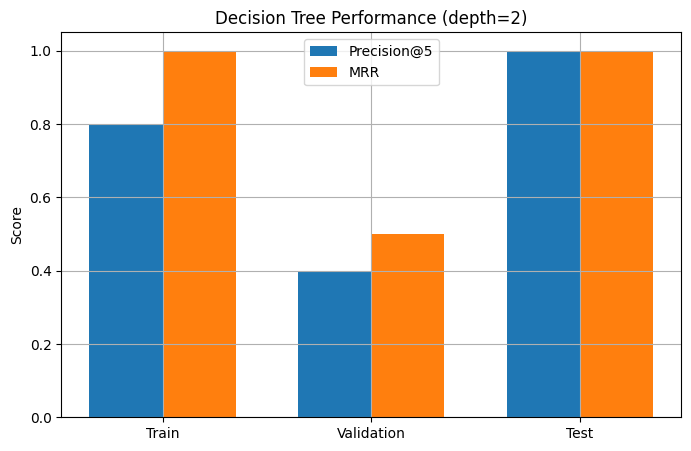

In [33]:
labels = ["Train", "Validation", "Test"]
precisions = [p_at_5_train, p_at_5_valid, p_at_5_test]
mrrs = [mrr_train, mrr_valid, mrr_test]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, precisions, width, label="Precision@5")
plt.bar(x + width/2, mrrs, width, label="MRR")
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title(f"Decision Tree Performance (depth={Last_tree.max_depth})")
plt.legend()
plt.grid(True)
plt.show()